<a href="https://colab.research.google.com/github/nisaa783/practical-statistics-for-data-scientists_Anisa-Khasanah/blob/main/chapter-01-exploratory-data-analysis/Chapter_1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 1: Exploratory Data Analysis (EDA)

Sebelum membangun model Machine Learning atau Deep Learning yang kompleks, langkah awal yang wajib dilakukan adalah **Exploratory Data Analysis (EDA)**. EDA bertujuan untuk memahami struktur data, mendeteksi anomali (*outlier*), melihat distribusi data, dan merangkum karakteristik inti dari dataset.

## 1. Estimasi Lokasi (Location Estimates)
Estimasi lokasi digunakan untuk mencari nilai pusat atau "rata-rata" dari distribusi data. Beberapa metrik utamanya meliputi:
* **Mean (Rata-rata):** Penjumlahan seluruh nilai dibagi dengan jumlah data. Sangat sensitif terhadap nilai ekstrim (*outlier*).
* **Median:** Nilai tengah dari data yang telah diurutkan dari terkecil ke terbesar. Lebih tahan terhadap *outlier* dibandingkan mean.
* **Trimmed Mean (Rata-rata Terpangkas):** Rata-rata yang dihitung setelah membuang sejumlah persentase data tertentu di bagian ujung bawah dan atas (misalnya membuang 10% data terbawah dan 10% teratas). Ini membantu meredam efek *outlier*.

## 2. Estimasi Variabilitas (Variability Estimates)
Estimasi variabilitas mengukur seberapa menyebar atau beragamnya data dari nilai pusatnya:
* **Variance & Standard Deviation:** Ukuran penyebaran standar yang sensitif terhadap nilai ekstrim.
* **Interquartile Range (IQR):** Selisih antara persentil ke-75 ($Q3$) dan persentil ke-25 ($Q1$). Sangat aman digunakan jika data memiliki banyak *outlier*.

## 3. Visualisasi Data
Visualisasi membantu melihat bentuk distribusi data secara intuitif. Contohnya adalah **Box Plot**, yang menampilkan ringkasan lima angka (*five-number summary*: minimum, $Q1$, median, $Q3$, maksimum) serta mendeteksi keberadaan *outlier*.

--- 5 Baris Pertama Dataset State ---


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA



--- Hasil Estimasi Lokasi Populasi ---
Mean          : 6,162,876.30
Median        : 4,436,369.50
Trimmed Mean  : 4,783,697.12


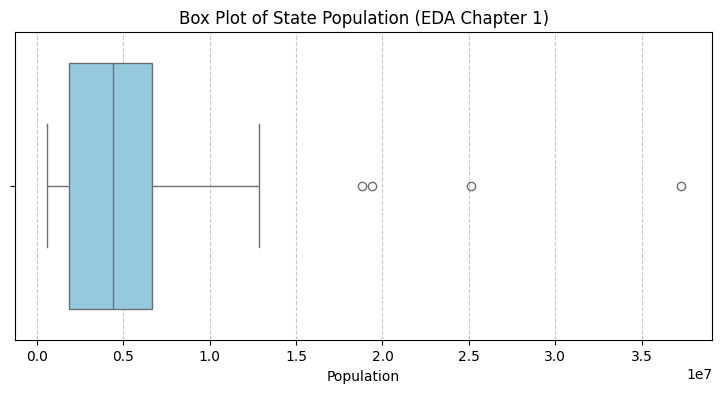

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menarik dataset 'state.csv' langsung dari link Raw GitHub penulis
# Tanpa perlu download manual ke komputer, data langsung diambil secara online
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/state.csv"
state = pd.read_csv(url)

# Menampilkan 5 baris pertama dari dataset untuk memeriksa struktur data
print("--- 5 Baris Pertama Dataset State ---")
display(state.head())

# 2. Menghitung estimasi lokasi (Mean, Median, dan Trimmed Mean) pada kolom Populasi
pop_mean = state['Population'].mean()
pop_median = state['Population'].median()
pop_trimmed = trim_mean(state['Population'], 0.1) # Membuang 10% data di ujung bawah & atas

print("\n--- Hasil Estimasi Lokasi Populasi ---")
print(f"Mean          : {pop_mean:,.2f}")
print(f"Median        : {pop_median:,.2f}")
print(f"Trimmed Mean  : {pop_trimmed:,.2f}")

# 3. Membuat visualisasi Box Plot untuk melihat distribusi dan mendeteksi outlier
plt.figure(figsize=(9, 4))
sns.boxplot(x=state['Population'], color='skyblue')
plt.title('Box Plot of State Population (EDA Chapter 1)')
plt.xlabel('Population')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Lanjutan Bab 1: Variabilitas dan Visualisasi Distribusi

Setelah memahami estimasi lokasi (nilai pusat), analisis data dilanjutkan dengan mengukur variabilitas dan melihat bentuk sebaran data secara lebih mendalam.

### 1. Estimasi Variabilitas (Variability Estimates)
Variabilitas mengukur seberapa jauh titik-titik data menyebar dari nilai rata-ratanya:
* **Standard Deviation (Standar Deviasi):** Akar kuadrat dari varians, menunjukkan rata-rata jarak penyimpangan data dari nilai mean.
* **Mean Absolute Deviation (MAD):** Rata-rata dari selisih absolut antara setiap nilai data dengan nilai median. Lebih tahan terhadap *outlier* dibanding standar deviasi.
* **Interquartile Range (IQR):** Jarak antara persentil ke-75 dan ke-25, sangat aman dari pengaruh *outlier* ekstrem.

### 2. Visualisasi Distribusi: Histogram dan Density Plot
* **Histogram:** Grafik batang yang membagi rentang data ke dalam interval (bin) tertentu untuk melihat frekuensi kemunculannya.
* **Density Plot (Kernel Density Estimate):** Versi halus dari histogram yang menyerupai kurva probabilitas, sangat berguna untuk melihat bentuk distribusi data (apakah normal, miring/skewed, dll).

--- Hasil Estimasi Variabilitas (Murder Rate) ---
Standard Deviation : 1.92
IQR (Q3 - Q1)      : 3.12
MAD (Median AbsDev): 1.60


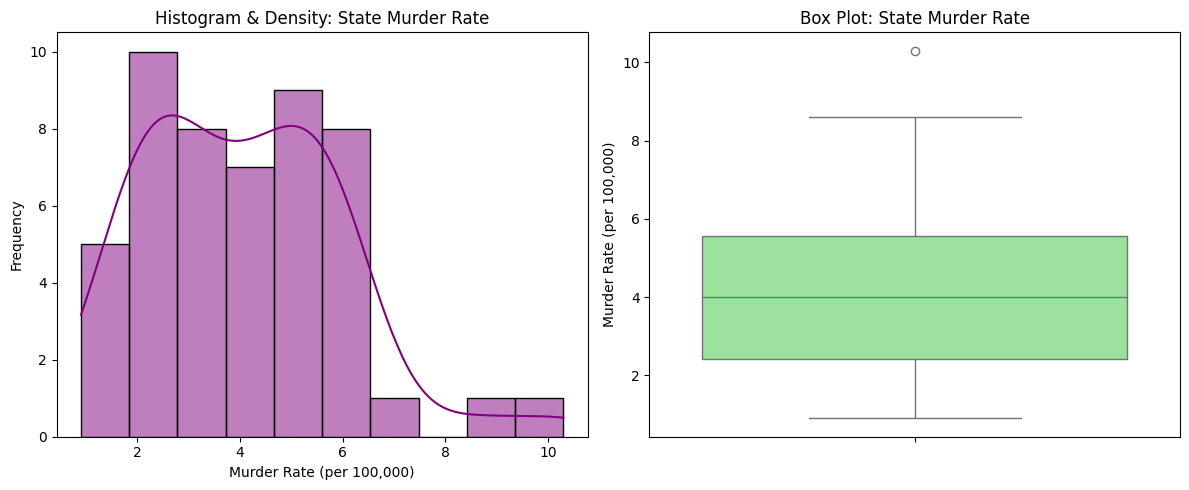

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menarik dataset 'state.csv' langsung dari link Raw GitHub penulis
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/state.csv"
state = pd.read_csv(url)

# 2. Menghitung Estimasi Variabilitas pada kolom 'Murder.Rate' (Tingkat Pembunuhan)
# Menggunakan Standard Deviation, IQR, dan MAD (Median Absolute Deviation)
murder_rate = state['Murder.Rate']

std_dev = murder_rate.std()
q75, q25 = np.percentile(murder_rate, [75, 25])
iqr = q75 - q25
mad = np.median(np.abs(murder_rate - murder_rate.median()))

print("--- Hasil Estimasi Variabilitas (Murder Rate) ---")
print(f"Standard Deviation : {std_dev:.2f}")
print(f"IQR (Q3 - Q1)      : {iqr:.2f}")
print(f"MAD (Median AbsDev): {mad:.2f}")

# 3. Membuat Visualisasi Histogram dan Density Plot untuk Murder Rate
plt.figure(figsize=(12, 5))

# Subplot 1: Histogram dengan garis KDE
plt.subplot(1, 2, 1)
sns.histplot(murder_rate, kde=True, color='purple', bins=10)
plt.title('Histogram & Density: State Murder Rate')
plt.xlabel('Murder Rate (per 100,000)')
plt.ylabel('Frequency')

# Subplot 2: Box Plot untuk melihat outlier dari Murder Rate
plt.subplot(1, 2, 2)
sns.boxplot(y=murder_rate, color='lightgreen')
plt.title('Box Plot: State Murder Rate')
plt.ylabel('Murder Rate (per 100,000)')

plt.tight_layout()
plt.show()

## Analisis Data Kategorikal dan Statistik Deskriptif (Dataset Loans)

Selain data numerik murni, dalam Data Science kita sangat sering menemui **data kategorikal** (data non-angka seperti status pinjaman, kategori pekerjaan, atau tingkat risiko).

### 1. Eksplorasi Data Kategorikal
* **Modus (Mode):** Kategori yang paling sering muncul dalam suatu fitur.
* **Expected Value (Nilai Harapan):** Nilai rata-rata dari suatu hasil yang dikalikan dengan probabilitas kejadiannya masing-masing.
* **Bar Chart / Count Plot:** Visualisasi standar untuk melihat frekuensi kemunculan dari setiap kategori.

### 2. Statistik Ringkasan pada Data Keuangan
Pada dataset pinjaman (*loans*), kita bisa melihat bagaimana distribusi jumlah pinjaman (*loan amount*) serta proporsi status pinjaman menggunakan statistik deskriptif dan visualisasi grafik batang.

--- 5 Baris Pertama Dataset Loans Income ---


,x
0,67000
1,52000
2,100000
3,78762
4,37041



--- Hasil Statistik Pendapatan Peminjam ---
Mean Income   : $68,760.52
Median Income : $62,000.00
IQR Income    : $40,000.00


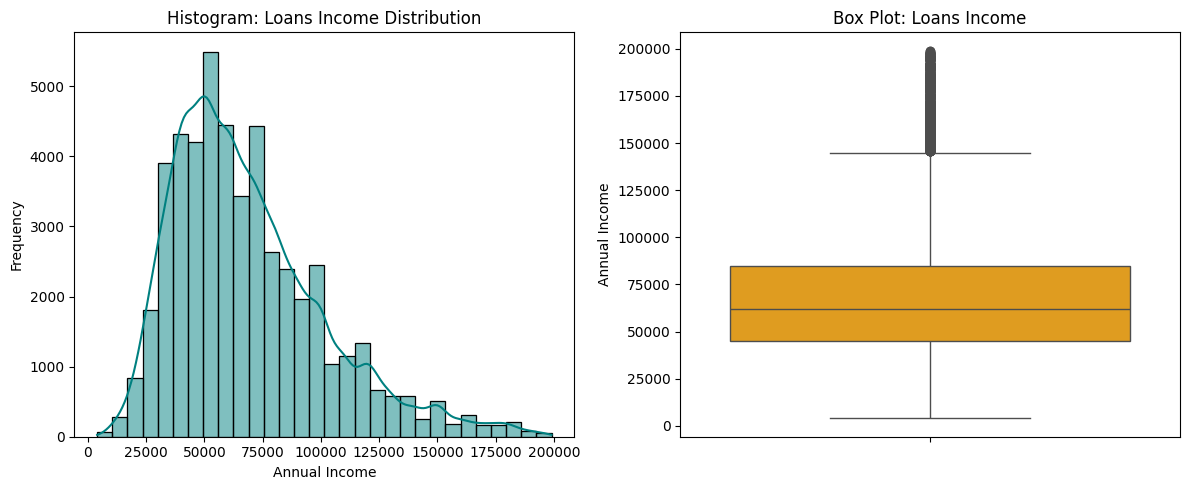

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Memperbaiki URL ke nama file yang benar di repository penulis ('loans_income.csv')
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loans_income.csv"
loans_income = pd.read_csv(url)

# Menampilkan 5 baris pertama untuk melihat struktur data pendapatan peminjam
print("--- 5 Baris Pertama Dataset Loans Income ---")
display(loans_income.head())

# 2. Menghitung statistik deskriptif dasar (Mean, Median, dan Quantile) dari pendapatan
income = loans_income.squeeze() # Mengubah dataframe menjadi series agar mudah dihitung

mean_val = income.mean()
median_val = income.median()
q75, q25 = income.quantile([0.75, 0.25])
iqr_val = q75 - q25

print("\n--- Hasil Statistik Pendapatan Peminjam ---")
print(f"Mean Income   : ${mean_val:,.2f}")
print(f"Median Income : ${median_val:,.2f}")
print(f"IQR Income    : ${iqr_val:,.2f}")

# 3. Membuat Visualisasi Histogram dan Box Plot untuk Pendapatan Peminjam
plt.figure(figsize=(12, 5))

# Subplot 1: Histogram dengan kurva Density (KDE)
plt.subplot(1, 2, 1)
sns.histplot(income, bins=30, kde=True, color='teal')
plt.title('Histogram: Loans Income Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

# Subplot 2: Box Plot untuk melihat distribusi dan sebaran data ekstrem (outlier)
plt.subplot(1, 2, 2)
sns.boxplot(y=income, color='orange')
plt.title('Box Plot: Loans Income')
plt.ylabel('Annual Income')

plt.tight_layout()
plt.show()